<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


'wget' is not recognized as an internal or external command,
operable program or batch file.


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


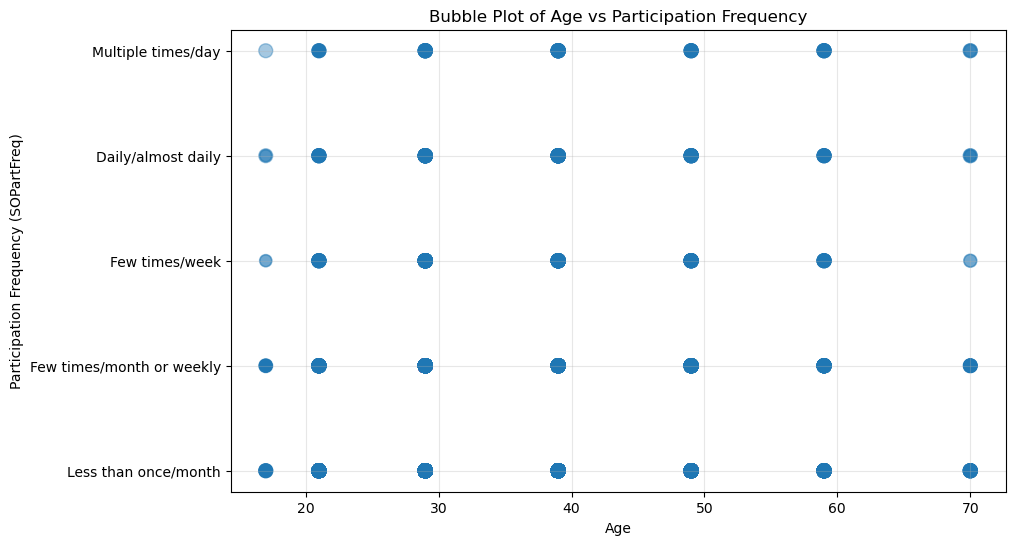

In [5]:
# Convert Age categories into approximate numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}

df['Age_Numeric'] = df['Age'].map(age_mapping)

# Convert JobSat to numeric
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')


sopartfreq_mapping = {
    'Less than once per month or monthly': 1,
    'A few times per month or weekly': 2,
    'A few times per week': 3,
    'Daily or almost daily': 4,
    'Multiple times per day': 5
}

df['SOPartFreq_Numeric'] = df['SOPartFreq'].map(sopartfreq_mapping)

# Keep only needed columns
df_bubble = df[['Age_Numeric', 'SOPartFreq_Numeric', 'JobSat']].dropna()

# Create bubble plot
plt.figure(figsize=(10, 6))

plt.scatter(
    df_bubble['Age_Numeric'],
    df_bubble['SOPartFreq_Numeric'],
    s=df_bubble['JobSat'] * 10,   # bubble size based on JobSat
    alpha=0.4
)

plt.title('Bubble Plot of Age vs Participation Frequency')
plt.xlabel('Age')
plt.ylabel('Participation Frequency (SOPartFreq)')

# Show original category labels on y-axis
plt.yticks(
    ticks=[1, 2, 3, 4, 5],
    labels=[
        'Less than once/month',
        'Few times/month or weekly',
        'Few times/week',
        'Daily/almost daily',
        'Multiple times/day'
    ]
)

plt.grid(True, alpha=0.3)
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


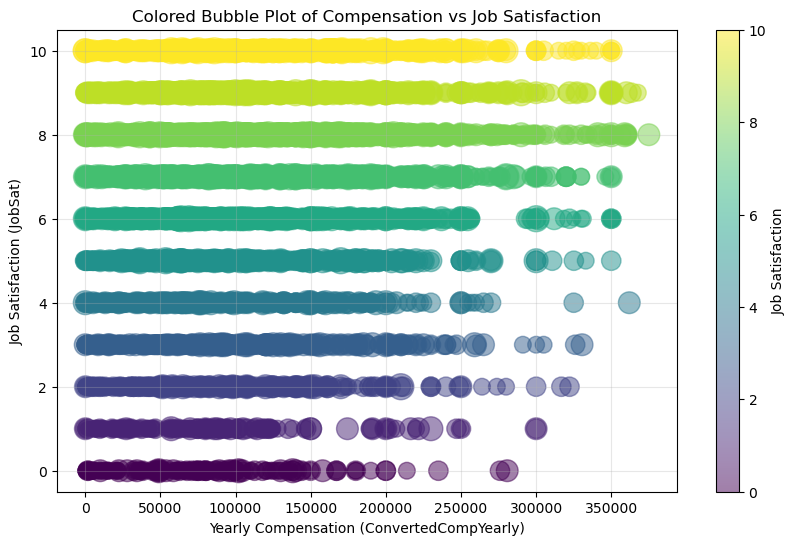

In [6]:
# Convert Age categories into approximate numeric values
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 70
}

df['Age_Numeric'] = df['Age'].map(age_mapping)

# Convert columns to numeric
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

# Keep only required columns
df_bubble = df[['ConvertedCompYearly', 'JobSat', 'Age_Numeric']].dropna()

# Remove extreme compensation outliers for better readability
upper_limit = df_bubble['ConvertedCompYearly'].quantile(0.99)
df_bubble = df_bubble[df_bubble['ConvertedCompYearly'] <= upper_limit]

# Create colored bubble plot
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df_bubble['ConvertedCompYearly'],
    df_bubble['JobSat'],
    s=df_bubble['Age_Numeric'] * 5,      # bubble size = age
    c=df_bubble['JobSat'],               # bubble color = job satisfaction
    alpha=0.5
)

plt.title('Colored Bubble Plot of Compensation vs Job Satisfaction')
plt.xlabel('Yearly Compensation (ConvertedCompYearly)')
plt.ylabel('Job Satisfaction (JobSat)')
plt.grid(True, alpha=0.3)

# Add colorbar
plt.colorbar(scatter, label='Job Satisfaction')

plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



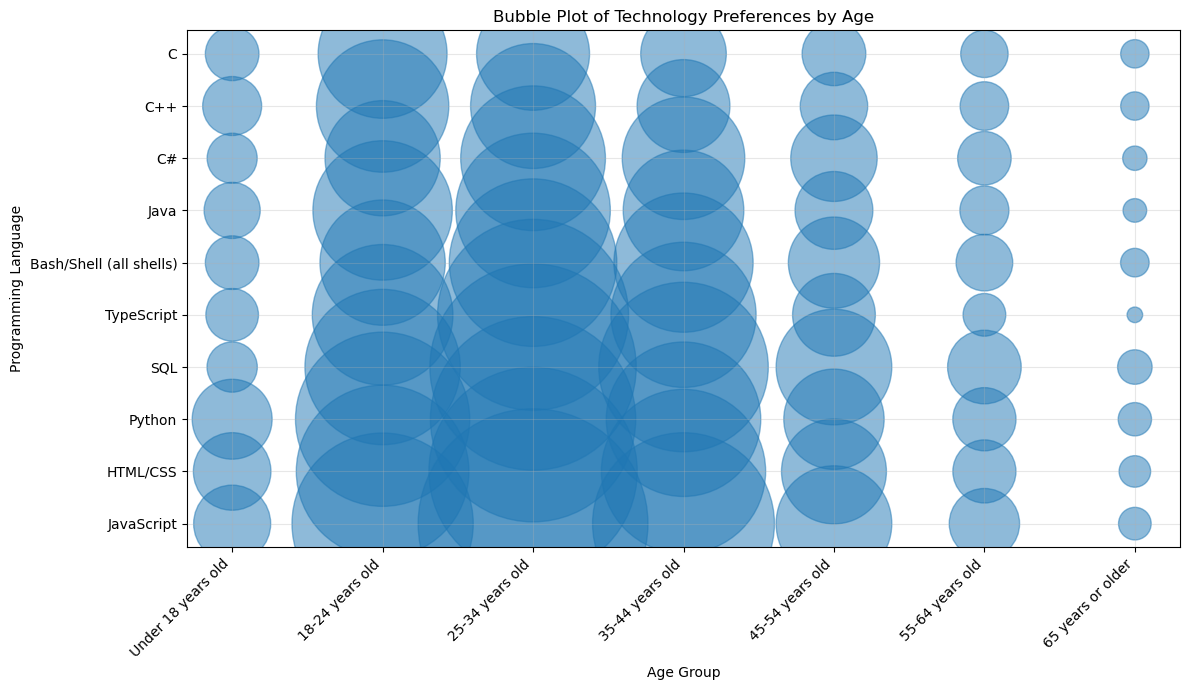

In [7]:
# Keep only needed columns
df_lang_age = df[['Age', 'LanguageHaveWorkedWith']].dropna()

# Split multiple languages separated by ;
df_lang_age['LanguageHaveWorkedWith'] = df_lang_age['LanguageHaveWorkedWith'].str.split(';')

# Expand each language into its own row
df_lang_age = df_lang_age.explode('LanguageHaveWorkedWith')

# Remove extra spaces
df_lang_age['LanguageHaveWorkedWith'] = df_lang_age['LanguageHaveWorkedWith'].str.strip()

# Use top 10 most common languages to keep the plot readable
top_languages = df_lang_age['LanguageHaveWorkedWith'].value_counts().head(10).index
df_lang_age = df_lang_age[df_lang_age['LanguageHaveWorkedWith'].isin(top_languages)]

# Define age group order
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Keep only known age groups
df_lang_age = df_lang_age[df_lang_age['Age'].isin(age_order)]

# Count frequency of each language within each age group
lang_age_counts = (
    df_lang_age
    .groupby(['Age', 'LanguageHaveWorkedWith'])
    .size()
    .reset_index(name='Frequency')
)

# Create numeric positions for plotting
age_to_num = {age: i for i, age in enumerate(age_order)}
lang_to_num = {lang: i for i, lang in enumerate(top_languages)}

lang_age_counts['Age_Num'] = lang_age_counts['Age'].map(age_to_num)
lang_age_counts['Lang_Num'] = lang_age_counts['LanguageHaveWorkedWith'].map(lang_to_num)

# Create bubble plot
plt.figure(figsize=(12, 7))

plt.scatter(
    lang_age_counts['Age_Num'],
    lang_age_counts['Lang_Num'],
    s=lang_age_counts['Frequency'] * 2,   # bubble size = frequency
    alpha=0.5
)

plt.title('Bubble Plot of Technology Preferences by Age')
plt.xlabel('Age Group')
plt.ylabel('Programming Language')

plt.xticks(
    ticks=range(len(age_order)),
    labels=age_order,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=range(len(top_languages)),
    labels=top_languages
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


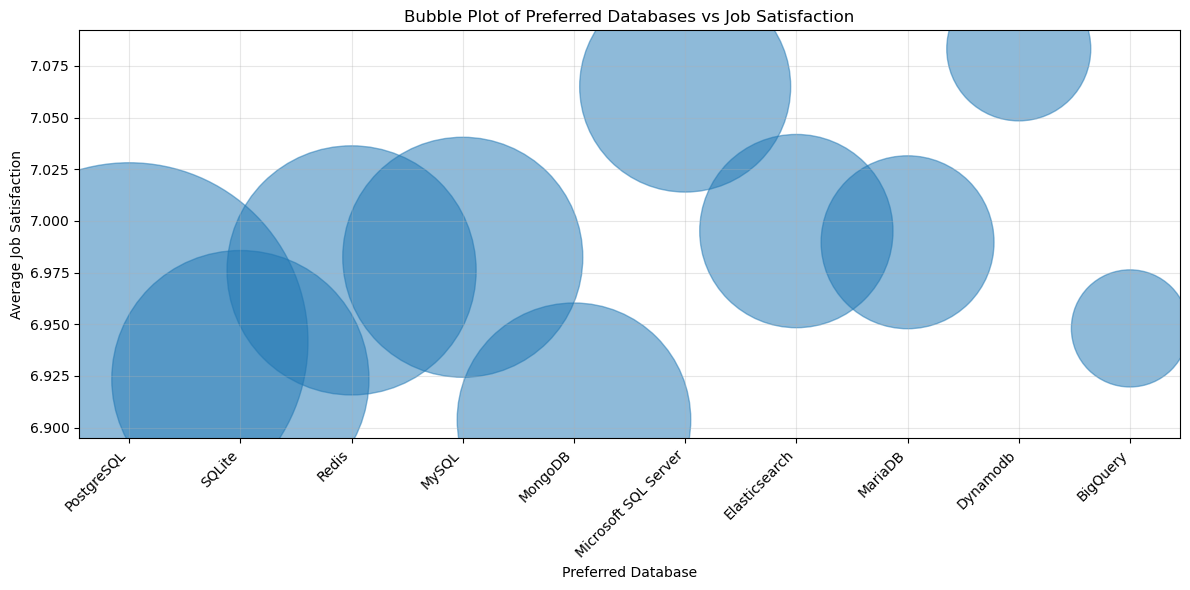

In [8]:
# Convert JobSat to numeric
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

# Keep only required columns
df_db = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

# Split multiple database values separated by ;
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.split(';')

# Expand each database into its own row
df_db = df_db.explode('DatabaseWantToWorkWith')

# Remove extra spaces
df_db['DatabaseWantToWorkWith'] = df_db['DatabaseWantToWorkWith'].str.strip()

# Group by database:
# - mean job satisfaction
# - number of respondents
db_summary = (
    df_db.groupby('DatabaseWantToWorkWith')
    .agg(
        Avg_JobSat=('JobSat', 'mean'),
        Respondent_Count=('JobSat', 'count')
    )
    .reset_index()
)

# Optional: keep top 10 databases for readability
db_summary = db_summary.sort_values('Respondent_Count', ascending=False).head(10)

# Create numeric x positions
x_positions = range(len(db_summary))

# Create bubble plot
plt.figure(figsize=(12, 6))

plt.scatter(
    x_positions,
    db_summary['Avg_JobSat'],
    s=db_summary['Respondent_Count'] * 5,   # bubble size = respondent count
    alpha=0.5
)

plt.title('Bubble Plot of Preferred Databases vs Job Satisfaction')
plt.xlabel('Preferred Database')
plt.ylabel('Average Job Satisfaction')

plt.xticks(
    ticks=x_positions,
    labels=db_summary['DatabaseWantToWorkWith'],
    rotation=45,
    ha='right'
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


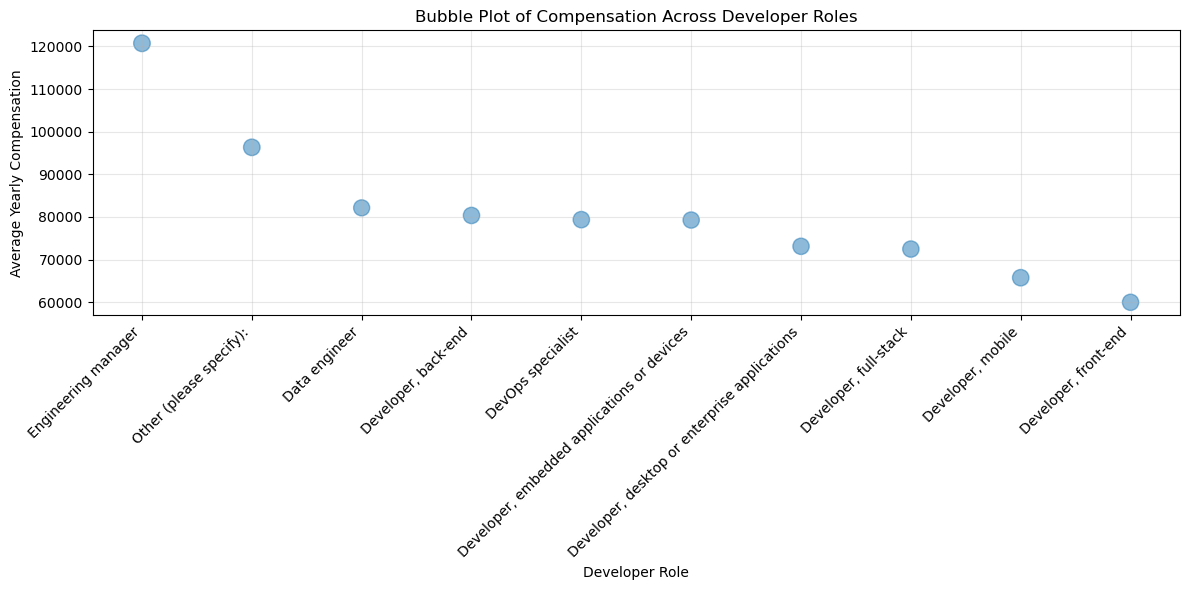

In [9]:
# Convert columns to numeric
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

# Keep only required columns
df_dev = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna()

# Split multiple developer roles separated by ;
df_dev['DevType'] = df_dev['DevType'].str.split(';')

# Expand roles into separate rows
df_dev = df_dev.explode('DevType')

# Remove extra spaces
df_dev['DevType'] = df_dev['DevType'].str.strip()

# Keep top 10 developer roles for readability
top_roles = df_dev['DevType'].value_counts().head(10).index
df_dev = df_dev[df_dev['DevType'].isin(top_roles)]

# Remove extreme compensation outliers
upper_limit = df_dev['ConvertedCompYearly'].quantile(0.99)
df_dev = df_dev[df_dev['ConvertedCompYearly'] <= upper_limit]

# Summarize by developer role
dev_summary = (
    df_dev.groupby('DevType')
    .agg(
        Avg_Compensation=('ConvertedCompYearly', 'mean'),
        Avg_JobSat=('JobSat', 'mean'),
        Count=('DevType', 'count')
    )
    .reset_index()
)

# Sort by compensation
dev_summary = dev_summary.sort_values('Avg_Compensation', ascending=False)

# Create x positions
x_positions = range(len(dev_summary))

# Create bubble plot
plt.figure(figsize=(12, 6))

plt.scatter(
    x_positions,
    dev_summary['Avg_Compensation'],
    s=dev_summary['Avg_JobSat'] * 20,   # bubble size = average job satisfaction
    alpha=0.5
)

plt.title('Bubble Plot of Compensation Across Developer Roles')
plt.xlabel('Developer Role')
plt.ylabel('Average Yearly Compensation')

plt.xticks(
    ticks=x_positions,
    labels=dev_summary['DevType'],
    rotation=45,
    ha='right'
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


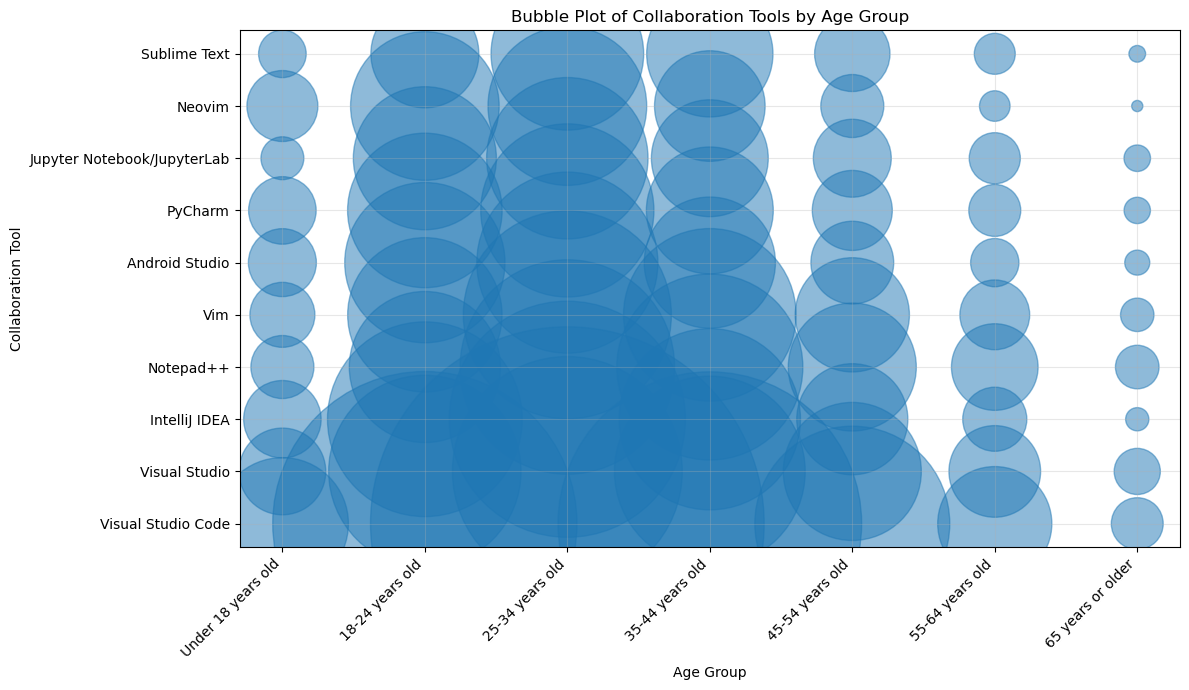

In [10]:
# Keep only needed columns
df_tools_age = df[['Age', 'NEWCollabToolsHaveWorkedWith']].dropna()

# Split multiple tools separated by ;
df_tools_age['NEWCollabToolsHaveWorkedWith'] = (
    df_tools_age['NEWCollabToolsHaveWorkedWith'].str.split(';')
)

# Expand each tool into its own row
df_tools_age = df_tools_age.explode('NEWCollabToolsHaveWorkedWith')

# Remove extra spaces
df_tools_age['NEWCollabToolsHaveWorkedWith'] = (
    df_tools_age['NEWCollabToolsHaveWorkedWith'].str.strip()
)

# Define age group order
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years or older'
]

# Keep only known age groups
df_tools_age = df_tools_age[df_tools_age['Age'].isin(age_order)]

# Use top 10 collaboration tools for readability
top_tools = (
    df_tools_age['NEWCollabToolsHaveWorkedWith']
    .value_counts()
    .head(10)
    .index
)

df_tools_age = df_tools_age[
    df_tools_age['NEWCollabToolsHaveWorkedWith'].isin(top_tools)
]

# Count frequency of each tool by age group
tool_age_counts = (
    df_tools_age
    .groupby(['Age', 'NEWCollabToolsHaveWorkedWith'])
    .size()
    .reset_index(name='Frequency')
)

# Convert age groups and tools into numeric positions
age_to_num = {age: i for i, age in enumerate(age_order)}
tool_to_num = {tool: i for i, tool in enumerate(top_tools)}

tool_age_counts['Age_Num'] = tool_age_counts['Age'].map(age_to_num)
tool_age_counts['Tool_Num'] = tool_age_counts['NEWCollabToolsHaveWorkedWith'].map(tool_to_num)

# Create bubble plot
plt.figure(figsize=(12, 7))

plt.scatter(
    tool_age_counts['Age_Num'],
    tool_age_counts['Tool_Num'],
    s=tool_age_counts['Frequency'] * 5,   # bubble size = frequency
    alpha=0.5
)

plt.title('Bubble Plot of Collaboration Tools by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Collaboration Tool')

plt.xticks(
    ticks=range(len(age_order)),
    labels=age_order,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=range(len(top_tools)),
    labels=top_tools
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



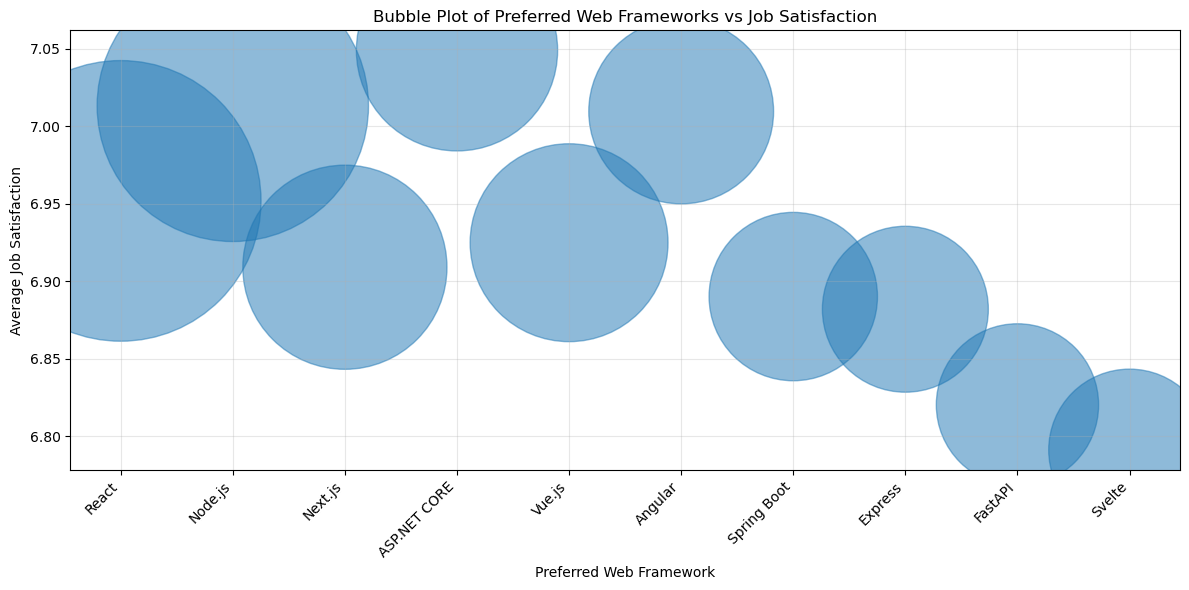

In [11]:
# Convert JobSat to numeric
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')

# Keep only required columns
df_web = df[['WebframeWantToWorkWith', 'JobSat']].dropna()

# Split multiple web frameworks separated by ;
df_web['WebframeWantToWorkWith'] = df_web['WebframeWantToWorkWith'].str.split(';')

# Expand each framework into its own row
df_web = df_web.explode('WebframeWantToWorkWith')

# Remove extra spaces
df_web['WebframeWantToWorkWith'] = df_web['WebframeWantToWorkWith'].str.strip()

# Group by framework:
# - average job satisfaction
# - number of respondents
web_summary = (
    df_web.groupby('WebframeWantToWorkWith')
    .agg(
        Avg_JobSat=('JobSat', 'mean'),
        Respondent_Count=('JobSat', 'count')
    )
    .reset_index()
)

# Keep top 10 frameworks for readability
web_summary = web_summary.sort_values('Respondent_Count', ascending=False).head(10)

# Create numeric x positions
x_positions = range(len(web_summary))

# Create bubble plot
plt.figure(figsize=(12, 6))

plt.scatter(
    x_positions,
    web_summary['Avg_JobSat'],
    s=web_summary['Respondent_Count'] * 5,   # bubble size = respondent count
    alpha=0.5
)

plt.title('Bubble Plot of Preferred Web Frameworks vs Job Satisfaction')
plt.xlabel('Preferred Web Framework')
plt.ylabel('Average Job Satisfaction')

plt.xticks(
    ticks=x_positions,
    labels=web_summary['WebframeWantToWorkWith'],
    rotation=45,
    ha='right'
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



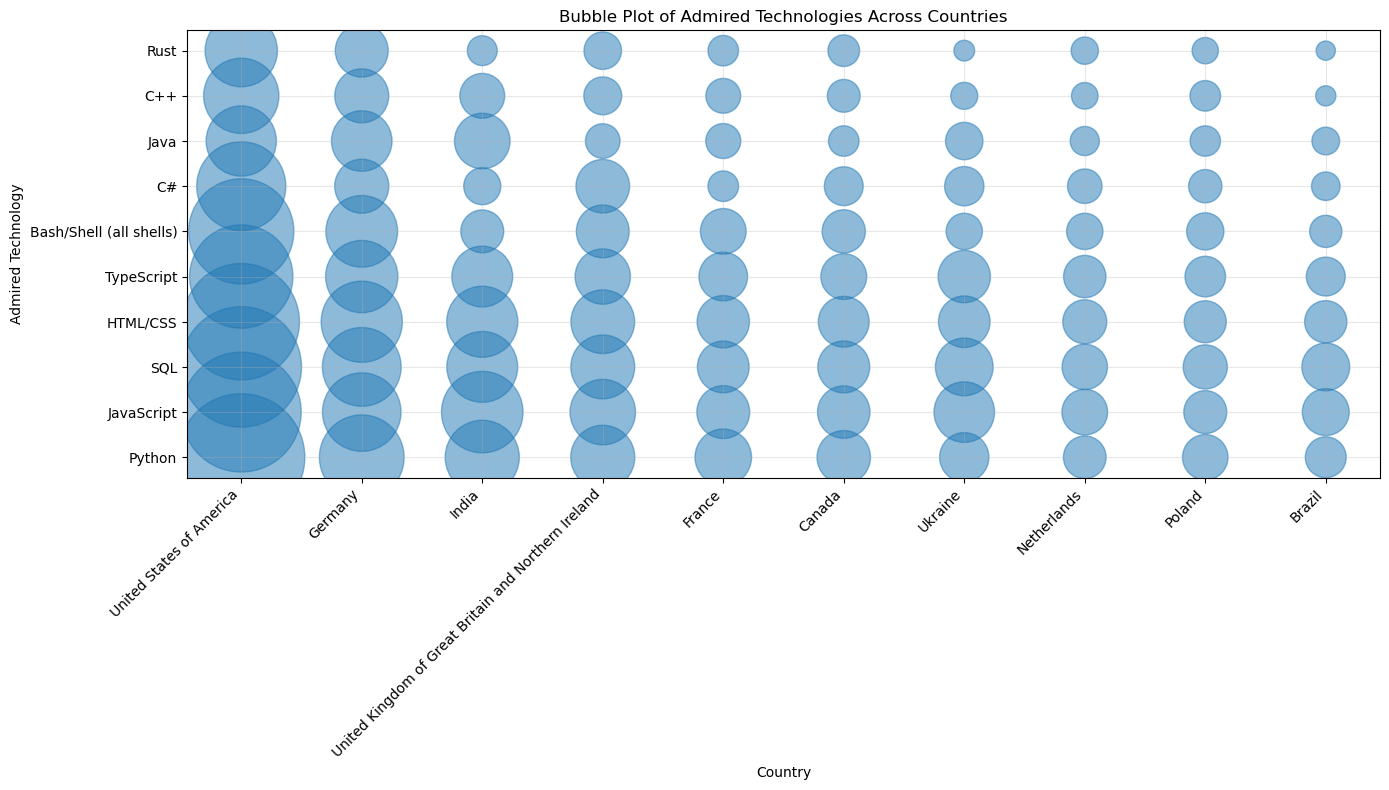

In [12]:
# Keep only required columns
df_admired = df[['Country', 'LanguageAdmired']].dropna()

# Split multiple admired technologies separated by ;
df_admired['LanguageAdmired'] = df_admired['LanguageAdmired'].str.split(';')

# Expand each technology into its own row
df_admired = df_admired.explode('LanguageAdmired')

# Remove extra spaces
df_admired['LanguageAdmired'] = df_admired['LanguageAdmired'].str.strip()

# Keep top 10 countries for readability
top_countries = df_admired['Country'].value_counts().head(10).index
df_admired = df_admired[df_admired['Country'].isin(top_countries)]

# Keep top 10 admired technologies for readability
top_technologies = df_admired['LanguageAdmired'].value_counts().head(10).index
df_admired = df_admired[df_admired['LanguageAdmired'].isin(top_technologies)]

# Count frequency of admiration by country and technology
admired_counts = (
    df_admired
    .groupby(['Country', 'LanguageAdmired'])
    .size()
    .reset_index(name='Frequency')
)

# Convert categories to numeric positions
country_to_num = {country: i for i, country in enumerate(top_countries)}
tech_to_num = {tech: i for i, tech in enumerate(top_technologies)}

admired_counts['Country_Num'] = admired_counts['Country'].map(country_to_num)
admired_counts['Tech_Num'] = admired_counts['LanguageAdmired'].map(tech_to_num)

# Create bubble plot
plt.figure(figsize=(14, 8))

plt.scatter(
    admired_counts['Country_Num'],
    admired_counts['Tech_Num'],
    s=admired_counts['Frequency'] * 2,   # bubble size = frequency
    alpha=0.5
)

plt.title('Bubble Plot of Admired Technologies Across Countries')
plt.xlabel('Country')
plt.ylabel('Admired Technology')

plt.xticks(
    ticks=range(len(top_countries)),
    labels=top_countries,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=range(len(top_technologies)),
    labels=top_technologies
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
